# Predicting Home Sale Prices and Identifying Real Estate Market Segments

This notebook works through the full EDA pipeline for the Ames Housing Dataset and closes with a baseline linear regression model. The notebook has multiple steps with more models to be added later:
   

1. Data loading and initial inspection
2. Missing value analysis
3. Target variable (SalePrice) distribution
4. Exploratory analysis of Numerical features
5. Exploratory analysis of Categorical features
6. Data cleaning and imputation
7. Feature engineering (8 new features)
8. Baseline linear regression model
9. Key findings summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Libraries loaded.')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Libraries loaded.


## 1. Data Loading and Initial Inspection

The Ames Housing Dataset is fetched directly from OpenML. It covers approximately 1,460 residential property sales in Ames, Iowa with around 80 features per property. The first download may take 20–30 seconds.

In [2]:
housing = fetch_openml(name='house_prices', as_frame=True, version=1)
df = housing.frame.copy()
df['SalePrice'] = df['SalePrice'].astype(float)

print(f'Dataset shape: {df.shape}')
print(f'Properties: {df.shape[0]}')
print(f'Total columns (features + target): {df.shape[1]}')
df.head()

Dataset shape: (1460, 81)
Properties: 1460
Total columns (features + target): 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [3]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

if 'SalePrice' in numerical_cols:
    numerical_cols.remove('SalePrice')

print(f'Numerical features : {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')
print()
print('SalePrice summary statistics:')
print(df['SalePrice'].describe().round(0))

Numerical features : 37
Categorical features: 43

SalePrice summary statistics:
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


## 2. Missing Value Analysis

Before modeling, we need to understand which columns have missing data and how much. Some missing values mean the property does not have that feature at all (e.g., no pool, no garage). Others are genuine data gaps that need imputation.

In [4]:
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0].sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(1)

missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})
print(f'Columns with missing values: {len(missing_df)}')
print()
print(missing_df)

Columns with missing values: 19

              Missing Count  Missing %
PoolQC                 1453       99.5
MiscFeature            1406       96.3
Alley                  1369       93.8
Fence                  1179       80.8
FireplaceQu             690       47.3
LotFrontage             259       17.7
GarageType               81        5.5
GarageYrBlt              81        5.5
GarageFinish             81        5.5
GarageQual               81        5.5
GarageCond               81        5.5
BsmtExposure             38        2.6
BsmtFinType2             38        2.6
BsmtFinType1             37        2.5
BsmtCond                 37        2.5
BsmtQual                 37        2.5
MasVnrArea                8        0.5
MasVnrType                8        0.5
Electrical                1        0.1


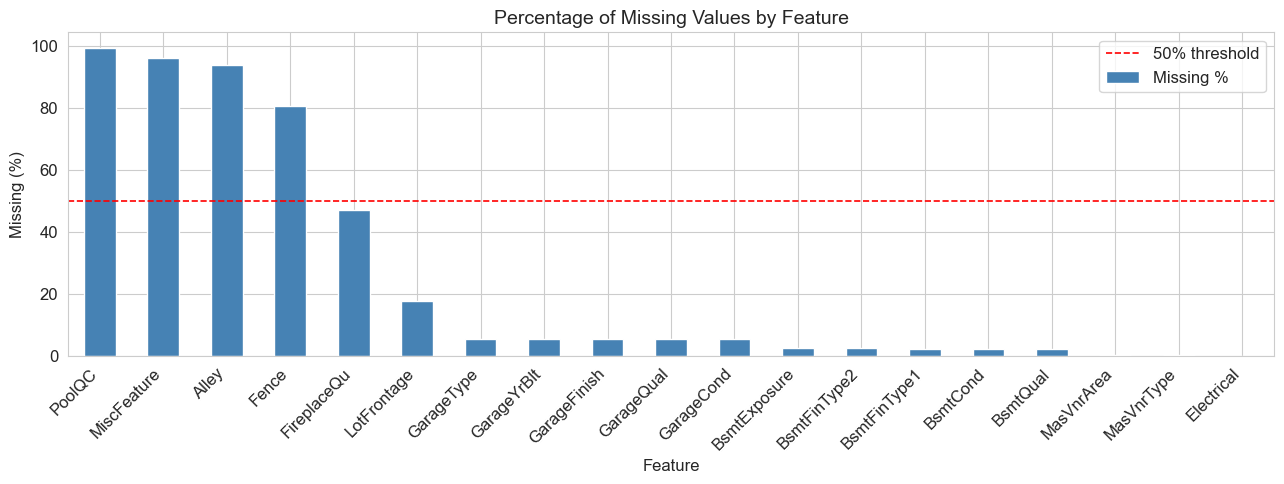

Interpretation:
  PoolQC, MiscFeature, Alley, Fence, FireplaceQu: NA means property lacks that feature.
  LotFrontage: genuine missing data — impute with median.


In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
missing_df['Missing %'].plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Percentage of Missing Values by Feature', fontsize=14)
ax.set_xlabel('Feature')
ax.set_ylabel('Missing (%)')
ax.axhline(y=50, color='red', linestyle='--', linewidth=1.2, label='50% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  PoolQC, MiscFeature, Alley, Fence, FireplaceQu: NA means property lacks that feature.')
print('  LotFrontage: genuine missing data — impute with median.')

## 3. Target variable (SalePrice) distribution

Understanding the distribution of the target variable is the first step in any regression analysis. If SalePrice is strongly skewed, a log transformation will produce a more symmetric distribution and generally leads to better model performance.

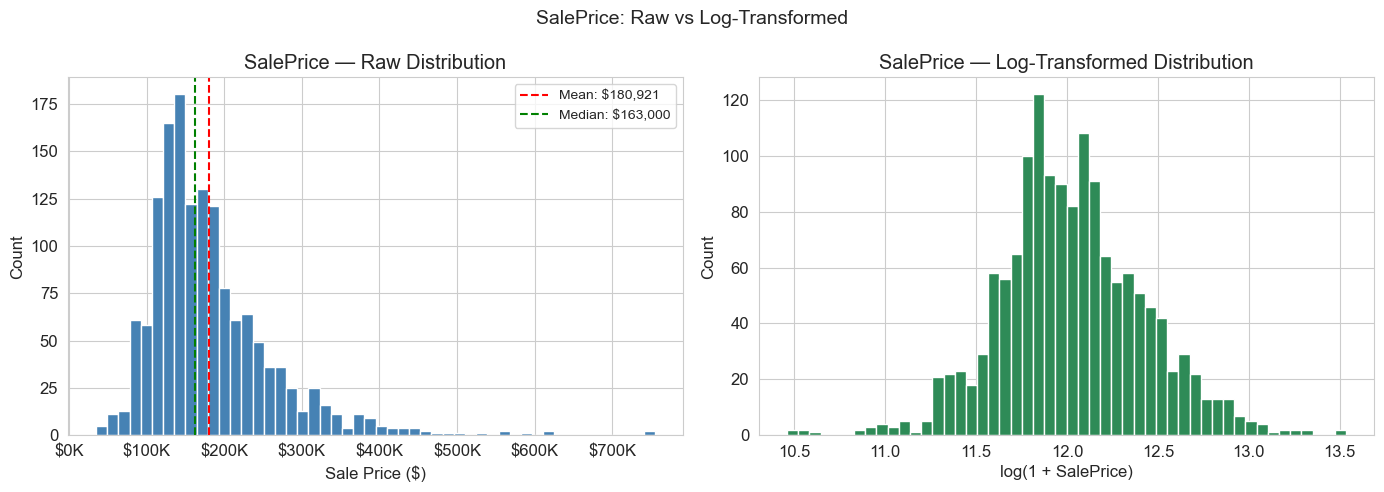

Raw skewness      : 1.883
Log-transformed   : 0.121
Min price         : $34,900
Max price         : $755,000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--',
                label=f'Mean: ${df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--',
                label=f'Median: ${df["SalePrice"].median():,.0f}')
axes[0].set_title('SalePrice — Raw Distribution')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

log_price = np.log1p(df['SalePrice'])
axes[1].hist(log_price, bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('SalePrice — Log-Transformed Distribution')
axes[1].set_xlabel('log(1 + SalePrice)')
axes[1].set_ylabel('Count')

plt.suptitle('SalePrice: Raw vs Log-Transformed', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Raw skewness      : {df["SalePrice"].skew():.3f}')
print(f'Log-transformed   : {log_price.skew():.3f}')
print(f'Min price         : ${df["SalePrice"].min():,.0f}')
print(f'Max price         : ${df["SalePrice"].max():,.0f}')

## 4. Exploratory analysis of Numerical features

We examine which numerical features are most strongly correlated with SalePrice. This guides both feature selection and tells us which variables are the most important price drivers.

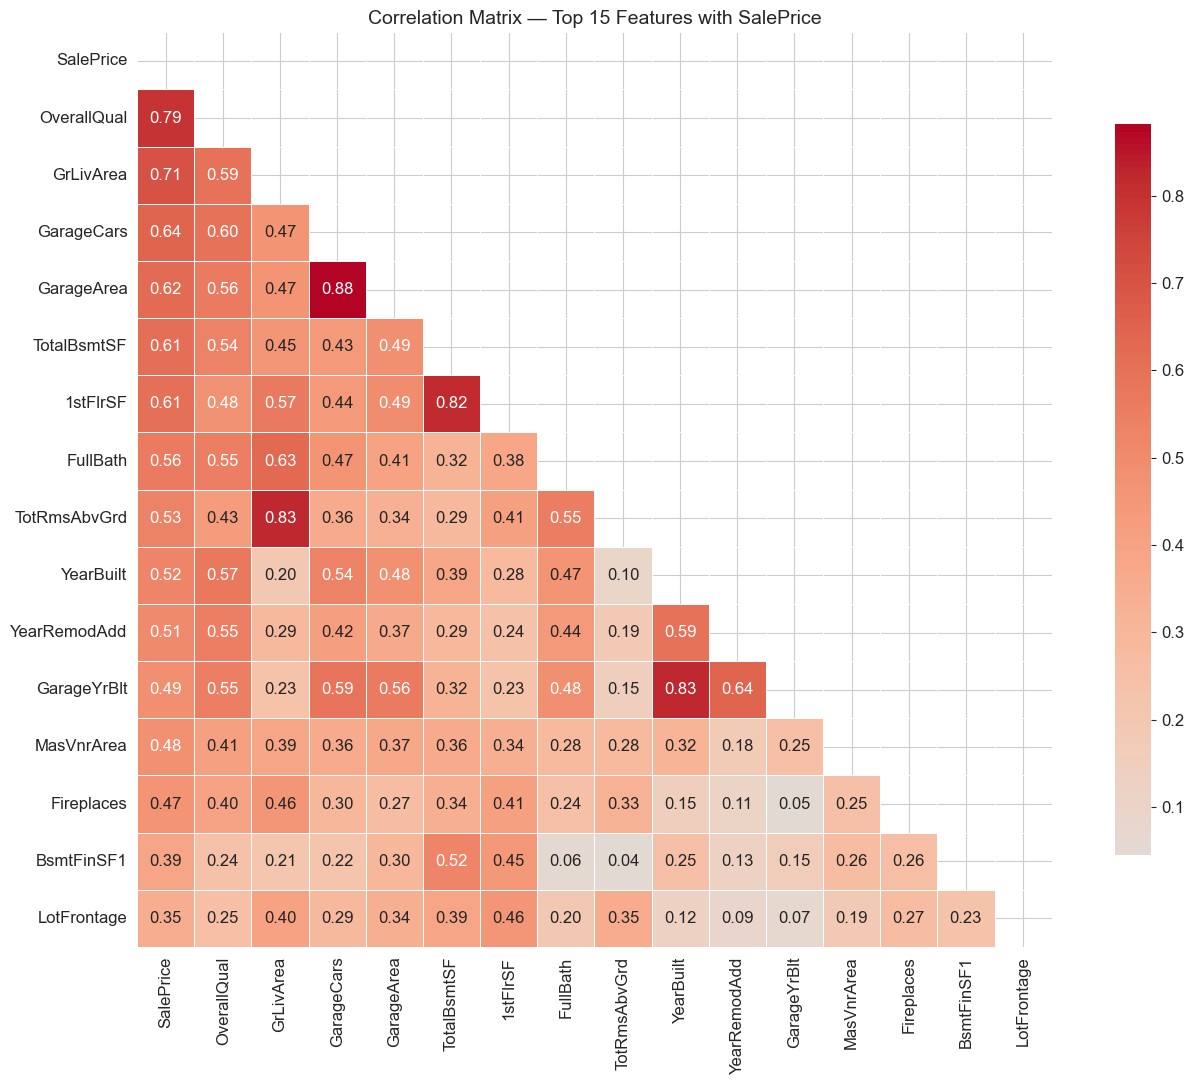

Top 10 numerical features correlated with SalePrice:
SalePrice       1.000
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
Name: SalePrice, dtype: float64


In [7]:
corr_matrix = df[numerical_cols + ['SalePrice']].corr()
top_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(16).index
top_corr = df[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(top_corr, dtype=bool))
sns.heatmap(top_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Top 15 Features with SalePrice', fontsize=14)
plt.tight_layout()
plt.show()

print('Top 10 numerical features correlated with SalePrice:')
print(corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(11).round(3))

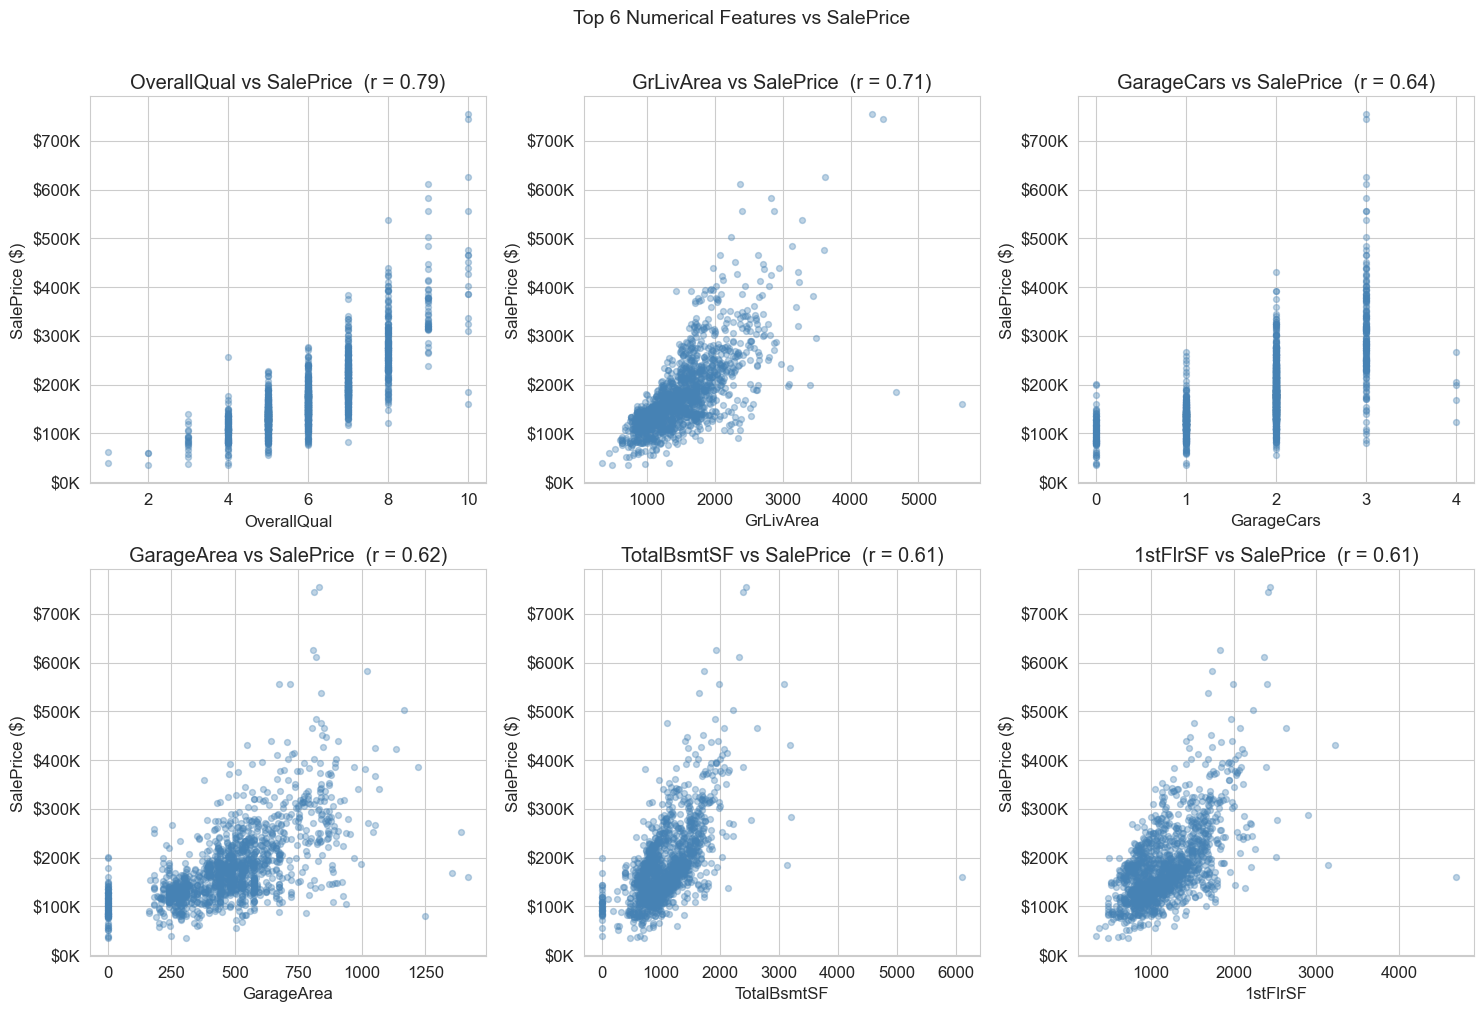

In [8]:
top_scatter = corr_matrix['SalePrice'].abs().sort_values(ascending=False).iloc[1:7].index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_scatter):
    r = corr_matrix['SalePrice'][feature]
    axes[i].scatter(df[feature], df['SalePrice'], alpha=0.35, color='steelblue', s=18)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('SalePrice ($)')
    axes[i].set_title(f'{feature} vs SalePrice  (r = {r:.2f})')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.suptitle('Top 6 Numerical Features vs SalePrice', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Exploratory analysis of Categorical features

Categorical variables like neighborhood, quality rating, and building type can explain large portions of price variation. Box plots reveal how much the price distribution shifts across categories.

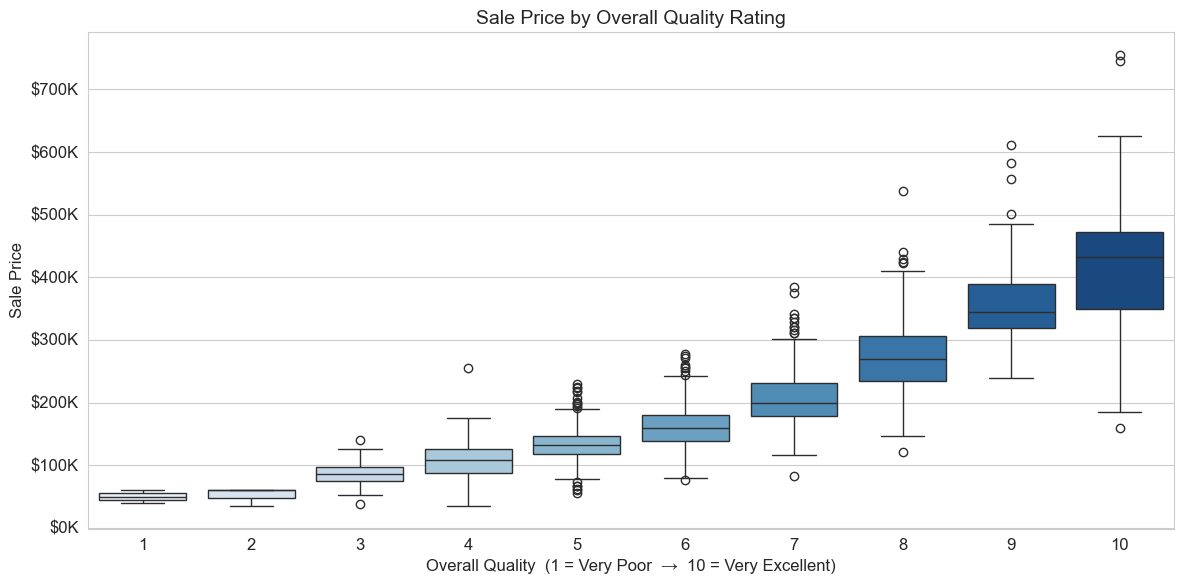

In [9]:
df_plot = df.copy()
df_plot['OverallQual'] = df_plot['OverallQual'].astype(float).astype(int)

fig, ax = plt.subplots(figsize=(12, 6))
order = sorted(df_plot['OverallQual'].unique())
sns.boxplot(data=df_plot, x='OverallQual', y='SalePrice', order=order,
            palette='Blues', ax=ax)
ax.set_title('Sale Price by Overall Quality Rating', fontsize=14)
ax.set_xlabel('Overall Quality  (1 = Very Poor  →  10 = Very Excellent)')
ax.set_ylabel('Sale Price')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

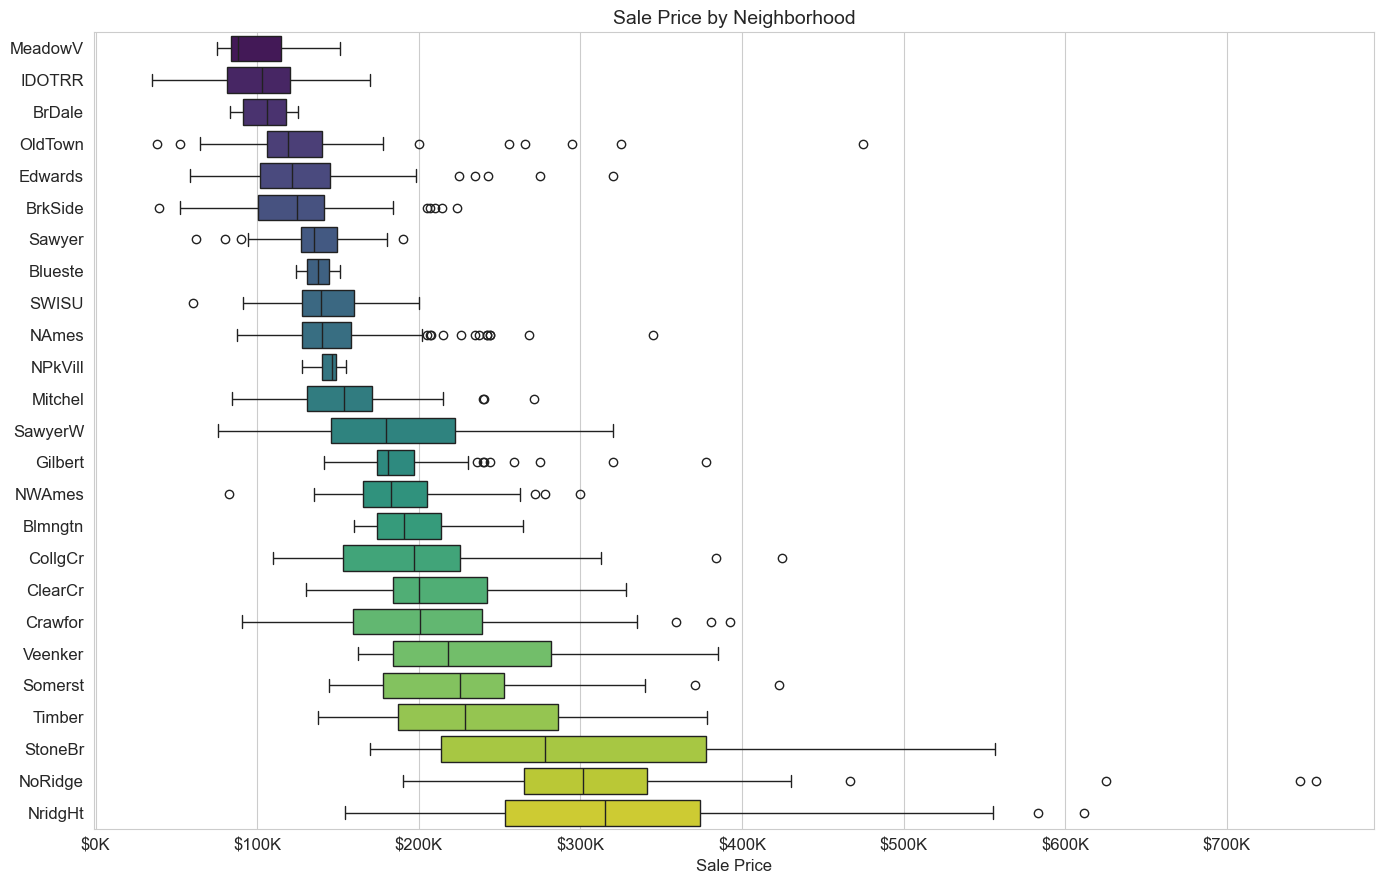

In [10]:
nb_order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index

fig, ax = plt.subplots(figsize=(14, 9))
sns.boxplot(data=df, x='SalePrice', y='Neighborhood', order=nb_order,
            palette='viridis', ax=ax)
ax.set_title('Sale Price by Neighborhood', fontsize=14)
ax.set_xlabel('Sale Price')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

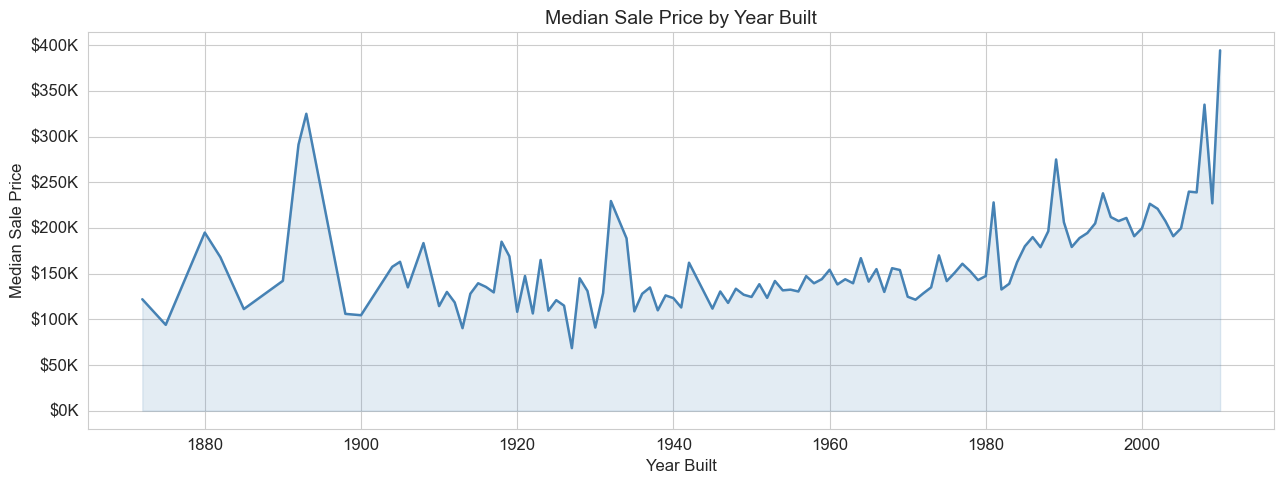

In [11]:
year_median = df.groupby('YearBuilt')['SalePrice'].median()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(year_median.index.astype(int), year_median.values, color='steelblue', linewidth=1.8)
ax.fill_between(year_median.index.astype(int), year_median.values, alpha=0.15, color='steelblue')
ax.set_title('Median Sale Price by Year Built', fontsize=14)
ax.set_xlabel('Year Built')
ax.set_ylabel('Median Sale Price')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

## 6. Data cleaning and imputation

Based on the missing value analysis, we apply two strategies:

- **Feature does not exist** (PoolQC, Alley, Garage, Basement, etc.): fill categorical NAs with `'None'` and numerical NAs with `0`.
- **Genuine missing data** (LotFrontage, others): fill with the median of the column.

We also remove two well-known outliers in GrLivArea — very large homes that sold for unusually low prices.

In [12]:
df_clean = df.copy()

none_cat_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_cat_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('None')

zero_num_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in zero_num_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

for col in df_clean.select_dtypes(exclude=[np.number]).columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

before = len(df_clean)
df_clean = df_clean[~((df_clean['GrLivArea'].astype(float) > 4000) &
                       (df_clean['SalePrice'] < 200000))]

print(f'Missing values remaining : {df_clean.isnull().sum().sum()}')
print(f'Outliers removed         : {before - len(df_clean)}')
print(f'Final dataset shape      : {df_clean.shape}')

Missing values remaining : 0
Outliers removed         : 2
Final dataset shape      : (1458, 81)


## 7. Feature Engineering

We create new features that combine or transform existing variables to capture relationships that the raw columns cannot express on their own. These engineered features are often stronger predictors.

In [13]:
df_clean['HouseAge'] = (df_clean['YrSold'].astype(int)
                        - df_clean['YearBuilt'].astype(int))

df_clean['YrsSinceRemodel'] = (df_clean['YrSold'].astype(int)
                                - df_clean['YearRemodAdd'].astype(int))

df_clean['TotalSF'] = (df_clean['TotalBsmtSF'].astype(float)
                       + df_clean['1stFlrSF'].astype(float)
                       + df_clean['2ndFlrSF'].astype(float))

df_clean['TotalBathrooms'] = (df_clean['FullBath'].astype(float)
                               + 0.5 * df_clean['HalfBath'].astype(float)
                               + df_clean['BsmtFullBath'].astype(float)
                               + 0.5 * df_clean['BsmtHalfBath'].astype(float))

df_clean['HasPool']      = (df_clean['PoolArea'].astype(float) > 0).astype(int)
df_clean['HasGarage']    = (df_clean['GarageArea'].astype(float) > 0).astype(int)
df_clean['HasBasement']  = (df_clean['TotalBsmtSF'].astype(float) > 0).astype(int)
df_clean['HasFireplace'] = (df_clean['Fireplaces'].astype(float) > 0).astype(int)

new_features = ['HouseAge', 'YrsSinceRemodel', 'TotalSF', 'TotalBathrooms',
                'HasPool', 'HasGarage', 'HasBasement', 'HasFireplace']

print('Engineered features summary:')
print(df_clean[new_features].describe().round(2))

Engineered features summary:
       HouseAge  YrsSinceRemodel  TotalSF  TotalBathrooms  HasPool  HasGarage  \
count   1458.00          1458.00  1458.00         1458.00  1458.00    1458.00   
mean      36.60            22.98  2557.15            2.21     0.00       0.94   
std       30.24            20.64   774.11            0.78     0.06       0.23   
min        0.00             0.00   334.00            1.00     0.00       0.00   
25%        8.00             4.00  2008.50            2.00     0.00       1.00   
50%       35.00            14.00  2473.00            2.00     0.00       1.00   
75%       54.00            41.00  3002.25            2.50     0.00       1.00   
max      136.00            60.00  6872.00            6.00     1.00       1.00   

       HasBasement  HasFireplace  
count      1458.00       1458.00  
mean          0.97          0.53  
std           0.16          0.50  
min           0.00          0.00  
25%           1.00          0.00  
50%           1.00          1.0

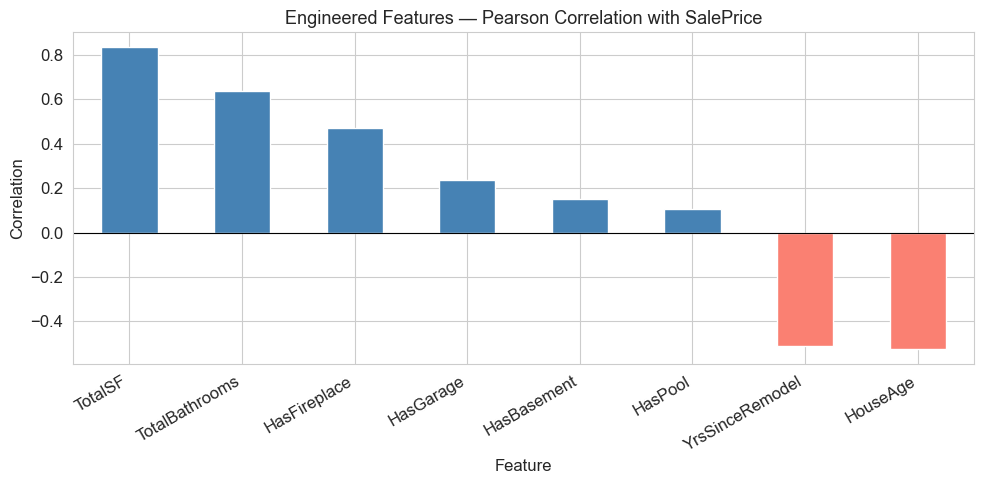

Correlations with SalePrice:
TotalSF            0.833
TotalBathrooms     0.636
HasFireplace       0.472
HasGarage          0.237
HasBasement        0.153
HasPool            0.104
YrsSinceRemodel   -0.510
HouseAge          -0.524
Name: SalePrice, dtype: float64


In [14]:
eng_corr = (df_clean[new_features + ['SalePrice']]
            .corr()['SalePrice']
            .drop('SalePrice')
            .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if v > 0 else 'salmon' for v in eng_corr.values]
eng_corr.plot(kind='bar', color=colors, edgecolor='white', ax=ax)
ax.set_title('Engineered Features — Pearson Correlation with SalePrice', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Correlation')
ax.axhline(y=0, color='black', linewidth=0.8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Correlations with SalePrice:')
print(eng_corr.round(3))

## 8. Baseline Model — Multiple Linear Regression

The baseline model gives us a performance benchmark to compare all future models against. We use multiple linear regression — the simplest regression approach — and report both **train error** and **test error** to assess whether the model generalizes or overfits.

The target is log-transformed (log1p) to handle skewness. Categorical columns are one-hot encoded.

In [15]:
df_model = df_clean.copy()
df_model['SalePrice'] = np.log1p(df_model['SalePrice'])

cat_cols = df_model.select_dtypes(exclude=[np.number]).columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

bool_cols = df_model.select_dtypes(include=['bool']).columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f'Features before encoding : {len(df_clean.columns) - 1}')
print(f'Features after encoding  : {df_model.shape[1] - 1}')
print(f'Dataset shape            : {df_model.shape}')

Features before encoding : 88
Features after encoding  : 267
Dataset shape            : (1458, 268)


In [16]:
X = df_model.drop('SalePrice', axis=1)
y = df_model['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 1166
Test samples     : 292
Features         : 267


In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test, y_test_pred)

print('Baseline Model — Multiple Linear Regression')
print('=' * 48)
print(f'  {"Metric":<28} {"Train":>8}  {"Test":>8}')
print(f'  {"-"*44}')
print(f'  {"RMSE (log scale)":<28} {train_rmse:>8.4f}  {test_rmse:>8.4f}')
print(f'  {"R\u00b2 Score":<28} {train_r2:>8.4f}  {test_r2:>8.4f}')
print('=' * 48)
print()
# Correct dollar-scale RMSE: invert log transform on predictions and actuals,
# then compute RMSE in the original price space.
train_dollar_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred)))
test_dollar_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(y_test_pred)))
print('Dollar-scale RMSE (inverse log transform applied to predictions):')
print(f'  Train : ${train_dollar_rmse:,.0f}')
print(f'  Test  : ${test_dollar_rmse:,.0f}')

Baseline Model — Multiple Linear Regression
  Metric                          Train      Test
  --------------------------------------------
  RMSE (log scale)               0.0863    0.1372
  R² Score                       0.9527    0.8884

Dollar-scale RMSE (inverse log transform applied to predictions):
  Train : $15,743
  Test  : $21,878


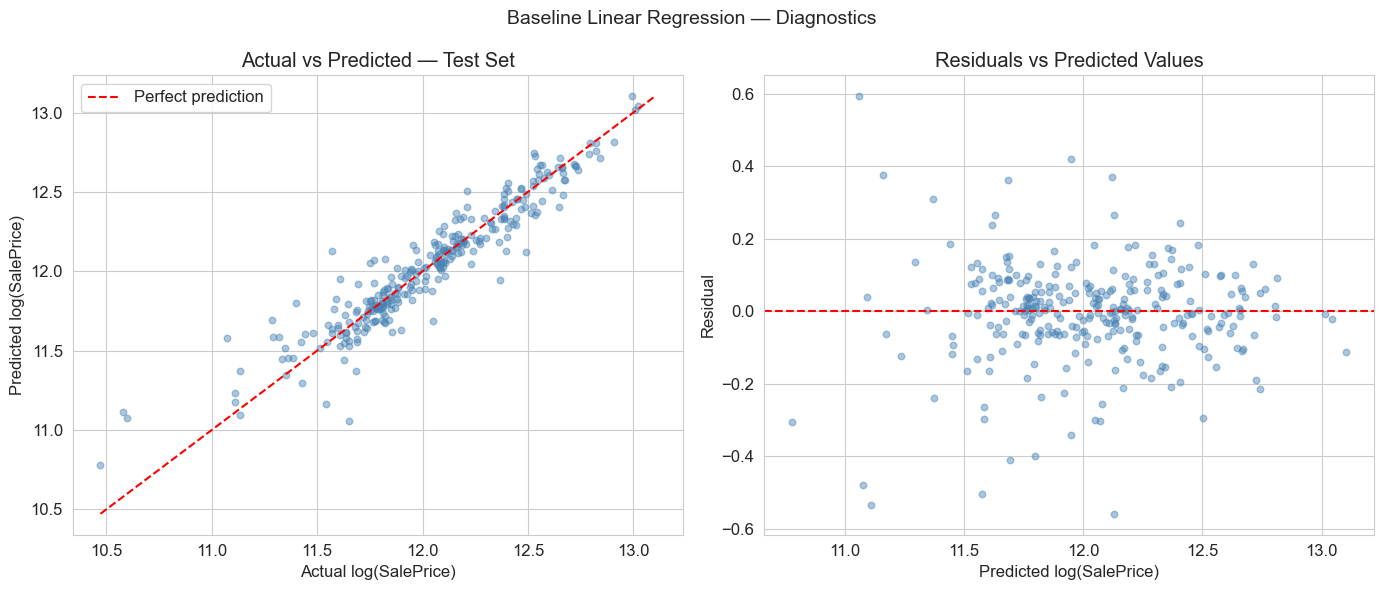

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_test_pred, alpha=0.45, color='steelblue', s=22)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5,
             label='Perfect prediction')
axes[0].set_title('Actual vs Predicted — Test Set')
axes[0].set_xlabel('Actual log(SalePrice)')
axes[0].set_ylabel('Predicted log(SalePrice)')
axes[0].legend()

residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.45, color='steelblue', s=22)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs Predicted Values')
axes[1].set_xlabel('Predicted log(SalePrice)')
axes[1].set_ylabel('Residual')

plt.suptitle('Baseline Linear Regression — Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

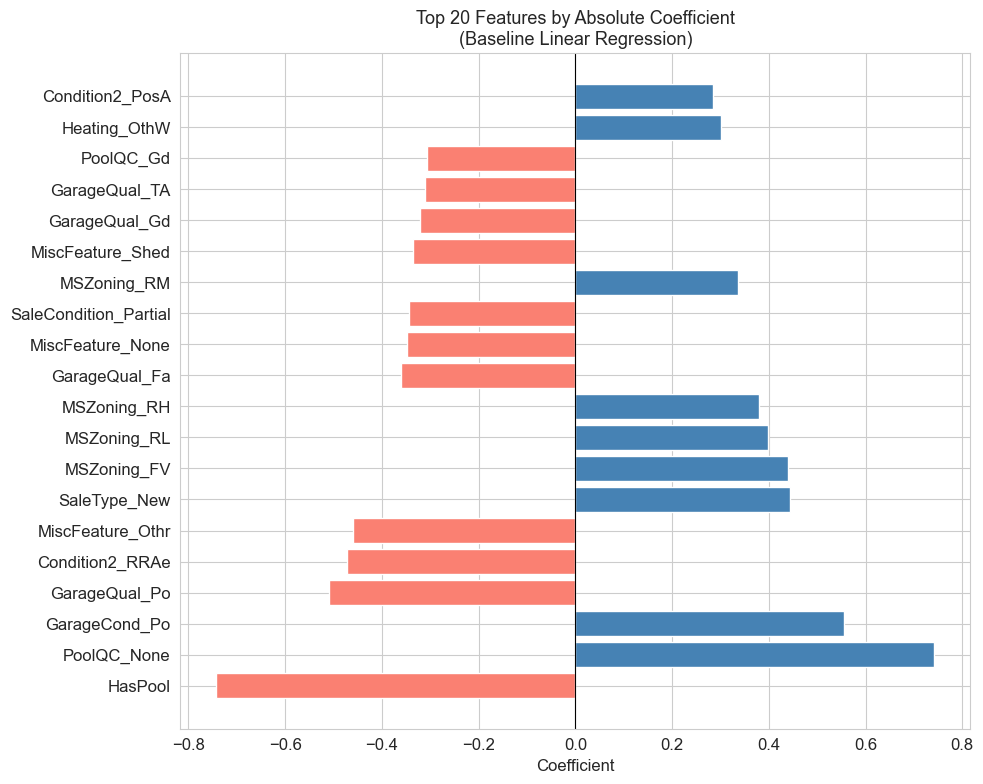

In [19]:
coef_df = (pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
           .assign(AbsCoef=lambda d: d['Coefficient'].abs())
           .sort_values('AbsCoef', ascending=False)
           .head(20))

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.set_title('Top 20 Features by Absolute Coefficient\n(Baseline Linear Regression)', fontsize=13)
ax.set_xlabel('Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 9. Key Findings — Module 23 Summary

### Data Quality
The dataset has 19 columns with missing values. For most of them (PoolQC, Alley, Fence, Garage, Basement columns), a missing value means the property genuinely does not have that feature — not a data entry error. After imputation and removal of 2 outliers, the dataset is fully clean.

### Target Variable
SalePrice is right-skewed (skewness ≈ 1.88), driven by a small number of very high-value properties. A log transformation normalises the distribution (skewness drops to 0.12) and is applied to the target in all models.

### Key Price Drivers (Numerical)
- **OverallQual** is the single strongest predictor (r ≈ 0.79). Homes rated 8–10 typically sell for double the price of homes rated 4–5.
- **GrLivArea** (above-ground living area) shows a strong linear relationship (r ≈ 0.71).
- **GarageCars** and **GarageArea** are highly correlated with each other and with price.
- The engineered **TotalSF** feature (r ≈ 0.83) outperforms any individual square footage column.
- **HouseAge** is negatively correlated — newer homes command higher prices.

### Key Price Drivers (Categorical)
- **Neighborhood** creates the largest categorical price spread. Top neighborhoods (NridgHt, NoRidge, StoneBr) have median prices 2–3× those of lower-tier neighborhoods.
- **YearBuilt** shows a clear upward price trend for homes built after 1980.

### Baseline Model Performance

| Metric | Train | Test |
|--------|-------|------|
| RMSE (log scale) | 0.0863 | 0.1372 |
| R² Score | 0.9527 | 0.8884 |

The gap between train R² and test R² indicates mild overfitting — expected for plain linear regression on a high-dimensional one-hot encoded feature matrix.